# Introduction

## 🎯 Objective

Linear Regression is one of the most fundamental supervised Machine Learning algorithms. It is used to model the relationship between input features and a continuous target variable.

The main objective of Linear Regression is to find the best-fit line that describes how the target variable changes with the input features.

In this notebook, we will learn the basic concepts of Linear Regression, its different types, and practical implementations using Python and Scikit-learn.

# What is Linear Regression?

Linear Regression is a statistical method used to model the relationship between a dependent variable (target) and one or more independent variables (features).

It predicts continuous numerical values by fitting a straight line (or hyperplane) that best represents the relationship between the variables.

Linear Regression assumes that the relationship between the input variables and the target variable is linear.

### Examples

- House Price Prediction
- Salary Prediction
- Sales Forecasting
- Temperature Prediction
- Weight Prediction

## Key Idea of Linear Regression

The Linear Regression equation is

y = β₀ + β₁x₁ + β₂x₂ + ------- + βₙxₙ + ε

Where:

- **y** → Dependent Variable (Target)
- **x₁, x₂, ..., xₙ** → Independent Variables (Features)
- **β₀** → Intercept
- **β₁, β₂, ..., βₙ** → Coefficients (Feature Weights)
- **ε** → Error Term (Noise)

The goal of Linear Regression is to estimate the best coefficient values that minimize the prediction error.

## Types of Linear Regression

There are several types of Linear Regression depending on the number of input features and the complexity of the relationship.

### Types

- Simple Linear Regression
- Multiple Linear Regression
- Polynomial Regression
- Ridge Regression
- Lasso Regression
- Elastic Net Regression

Each type is designed for different kinds of Machine Learning problems.

# 1. Simple Linear Regression

## What is Simple Linear Regression?

Simple Linear Regression uses **only one independent variable** to predict a continuous target variable.

The relationship between the feature and the target is represented by a straight line.

### Formula

y = β₀ + β₁x + ε

### Example

Predicting a person's weight using their height.

## 1.1 Geometric Intuition

Simple Linear Regression tries to fit the best possible straight line through the data points.

### Visualization

Imagine a scatter plot where:

- X-axis represents Height
- Y-axis represents Weight

Each blue point represents an actual observation.

The regression algorithm draws a straight line that minimizes the distance between the data points and the predicted values.

This line is called the **Best-Fit Line**.

### Best-Fit Line

y = β₀ + β₁x

Where

- **β₀** is the intercept.
- **β₁** is the slope of the line.

The slope tells us how much the target variable changes when the input increases by one unit.

## 1.2 Loss Function

Linear Regression minimizes the **Mean Squared Error (MSE)**.

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

Where

- **y** = Actual Value
- **ŷ** = Predicted Value

The smaller the MSE, the better the fitted regression line.

## 1.3 Code Example: Predicting Weight from Height

- Python code using Scikit-learn to implement Simple Linear Regression.

Slope (β1): 0.75
Intercept (β0): -63.5
Mean Squared Error: 1.5


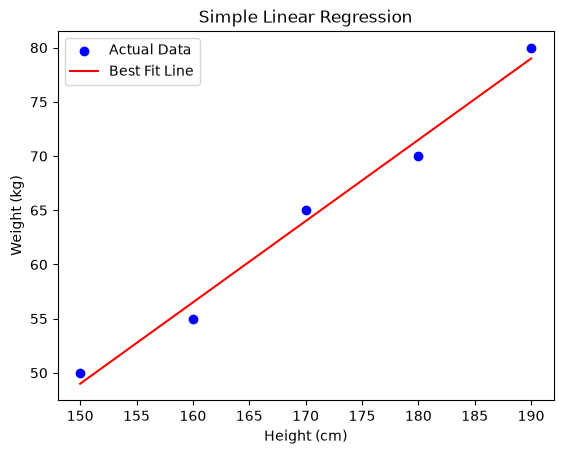

In [2]:
# Import Libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Example Dataset

heights = np.array([150,160,170,180,190])
weights = np.array([50,55,65,70,80])

# Reshape the feature array for Scikit-learn

heights = heights.reshape(-1,1)

# Create the Linear Regression model

model = LinearRegression()

# Train the model

model.fit(heights, weights)

# Predict weights

predicted_weights = model.predict(heights)

# Extract model parameters

slope = model.coef_[0]
intercept = model.intercept_

print("Slope (β1):", slope)
print("Intercept (β0):", intercept)

# Calculate Mean Squared Error

mse = mean_squared_error(weights, predicted_weights)

print("Mean Squared Error:", round(mse,2))

# Plot actual data

plt.scatter(heights, weights, color="blue", label="Actual Data")

# Plot regression line

plt.plot(heights, predicted_weights, color="red", label="Best Fit Line")

plt.title("Simple Linear Regression")
plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")

plt.legend()

plt.show()

## 1.4 Explanation of the Code

### Dataset

The dataset contains:

- Height → Independent Variable
- Weight → Dependent Variable

### Model Training

The `LinearRegression()` model automatically learns:

- Intercept (β₀)
- Slope (β₁)

### Prediction

The `predict()` function estimates the weight for each height value.

### Model Evaluation

The Mean Squared Error (MSE) measures how close the predictions are to the actual values.

Lower MSE indicates better model performance.

### Visualization

- Blue dots represent the actual observations.
- Red line represents the Best-Fit Line generated by Linear Regression.

## Expected Output

```
Slope (β1): 0.75

Intercept (β0): -63.5

Mean Squared Error: 1.50
```

- See a scatter plot with a red regression line showing the relationship between height and weight.

# 2. Multiple Linear Regression

Multiple Linear Regression is an extension of Simple Linear Regression.

It is used when the target variable depends on **more than one independent variable (feature).**

Instead of fitting a straight line, Multiple Linear Regression fits a **plane** (or a hyperplane when there are many features).

The model learns how each feature affects the target while keeping the other features constant.

---

## Example

Predicting House Price using:

- Number of Bedrooms
- House Area
- House Age

Target:

- House Price

## 2.1  Geometric Intuition

In Simple Linear Regression, we fit a straight line.

In Multiple Linear Regression, we fit a plane (or hyperplane for many features).

Imagine every house is represented as a point in multi-dimensional space.

The algorithm tries to find the best plane that minimizes the distance between the actual values and the predicted values.

The objective is to minimize the Residual Sum of Squares (RSS).

Formula:

y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ + ε

Where

- y = Target Variable
- x₁, x₂ ... = Features
- β₀ = Intercept
- β₁ ... βₙ = Feature Coefficients
- ε = Error Term

## 2.2 Python Implementation

In this example, we predict house prices using three features.

Features

- Bedrooms
- Area
- Age

Target

- Price

Coefficients (β1, β2, β3):
[1.66666667e+04 1.66650002e+02 1.66650002e+00]

Intercept (β0):
99999.99999999994

Mean Squared Error: 0.0
R² Score: 1.0


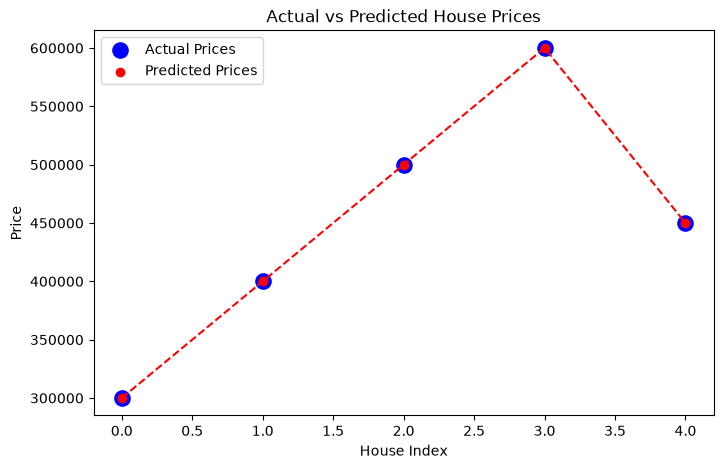

In [5]:
# Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Example Data

data = {
    "Bedrooms": [2, 3, 4, 5, 3],
    "Area": [1000, 1500, 2000, 2500, 1800],
    "Age": [10, 15, 20, 25, 18],
    "Price": [300000, 400000, 500000, 600000, 450000]
}

# Convert dictionary into DataFrame
df = pd.DataFrame(data)

# Separate Features and Target

x = df[["Bedrooms", "Area", "Age"]] # Independent Variables

y = df["Price"]# Dependent Variable

# Create Linear Regression Model

model = LinearRegression()

# Train the Model

model.fit(x,y)

# Make Predictions

predicted_prices = model.predict(x)

# Display Model Parameters

print("Coefficients (β1, β2, β3):")
print(model.coef_)

print("\nIntercept (β0):")
print(model.intercept_)

# Evaluate Model Performance

mse = mean_squared_error(y, predicted_prices)
r2 = r2_score(y, predicted_prices)

print("\nMean Squared Error:", round(mse,2))
print("R² Score:", round(r2,2))

# Visualization

plt.figure(figsize=(8,5))

plt.scatter(range(len(y)), y, s=120, color="blue", label="Actual Prices")

plt.scatter(range(len(predicted_prices)), predicted_prices, color = "red", label="Predicted Prices")

plt.plot(range(len(predicted_prices)), predicted_prices, color="red", linestyle="--")

plt.title("Actual vs Predicted House Prices")
plt.xlabel("House Index")
plt.ylabel("Price")

plt.legend()
plt.show()

## 2.3 Code Explanation

### Step 1

We imported the required libraries.

- NumPy
- Pandas
- Matplotlib
- Scikit-Learn

---

### Step 2

We created a small dataset containing:

- Bedrooms
- Area
- Age
- Price

---

### Step 3

We separated the dataset into:

- X → Features
- y → Target

---

### Step 4

We created a Multiple Linear Regression model.

```python
model = LinearRegression()
```

---

### Step 5

The model was trained using:

```python
model.fit(X, y)
```

The algorithm learns:

- Intercept (β₀)
- Feature Coefficients (β₁, β₂, β₃)

---

### Step 6

Predictions were generated using:

```python
model.predict(X)
```

---

### Step 7

We evaluated the model using:

- Mean Squared Error (MSE)
- R² Score

---

### Step 8

Finally, we visualized the Actual and Predicted House Prices.

## 2.4 Expected Output

You will see:

### Coefficients

```
[ β1  β2  β3 ]
```

These values show how much each feature affects the house price.

---

### Intercept

```
β₀
```

This is the predicted price when all feature values are zero.

---

### Mean Squared Error (MSE)

A lower MSE indicates better predictions.

---

### R² Score

An R² score closer to **1** indicates that the model explains most of the variation in the target variable.

---

### Visualization

The graph contains:

- 🔵 Blue points → Actual Prices
- 🔴 Red points → Predicted Prices

If both are close together, the model has learned the relationship well.

---

## 📝 Note

Multiple Linear Regression is useful when a target variable depends on several input features. It helps understand how each feature contributes to the prediction while considering all other features together.

# 3. Polynomial Linear Regression

## 🎯 What is Polynomial Linear Regression?

Polynomial Regression is an extension of Linear Regression that is used when the relationship between the input feature and the target variable is **non-linear**.

Instead of fitting a straight line, Polynomial Regression fits a **curve** by adding higher-degree terms such as **x², x³, x⁴**, etc.

Although the relationship becomes non-linear, the model is still considered a **Linear Regression** model because it remains linear with respect to the coefficients.

## 3.1 Geometric Intuition

Simple Linear Regression fits a straight line.

However, many real-world datasets follow a curved pattern instead of a straight line.

Polynomial Regression transforms the original feature into polynomial features, allowing the model to fit a smooth curve.

Examples:

- Degree 2 → Parabolic Curve
- Degree 3 → Cubic Curve
- Higher Degree → More Flexible Curve

The objective is still the same:

**Find the best-fit curve that minimizes the prediction error.**

## 📌 Polynomial Regression Equation

$$
y = \beta_0 + \beta_1x + \beta_2x^2 + \beta_3x^3 + \cdots + \beta_nx^n + \epsilon
$$

Where:

- **y** = Target Variable
- **x** = Input Feature
- **β₀** = Intercept
- **β₁, β₂, ...** = Feature Coefficients
- **ε** = Error Term

## Example

Suppose we want to predict the **failure rate of a machine** over time.

As time increases, the failure rate does not increase in a straight line.

Instead, it follows a curved trend.

Polynomial Regression is a better choice for modelling this relationship.

## 3.2 Python Implementation Using Scikit-Learn

In [6]:
# Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

# Dataset

# Time (Independent Variable)
time = np.array([1,2,3,4,5,6,7,8,9,10])

# Failure Rate (Dependent Variable)
failure_rate = np.array([5,7,15,30,55,90,130,180,250,350])

# Reshape data for Scikit-Learn
time = time.reshape(-1,1)

# Create polynomial features (Degree = 3)
poly = PolynomialFeatures(degree = 3)

# Transform original feature into polynomial features
time_poly = poly.fit_transform(time)

# Create Linear Regression model
model = LinearRegression()

# Train the model
model.fit(time_poly, failure_rate)

# Predict failure rates
predicted_failure_rate = model.predict(time_poly)

# Display model parameters
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

# Evaluate the model
mse = mean_squared_error(failure_rate, predicted_failure_rate)
r2 = r2_score(failure_rate, predicted_failure_rate)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.2f}")

Coefficients: [ 0.          4.78749029 -0.48543124  0.3482906 ]
Intercept: -1.7999999999992724
Mean Squared Error: 12.08
R-squared Score: 1.00


## 3.3 Visualization

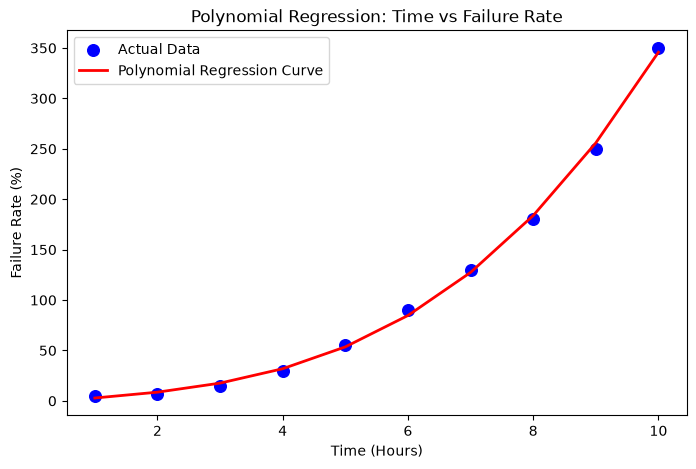

In [8]:
plt.figure(figsize=(8,5))

# Plot actual data points
plt.scatter(time, failure_rate, color="blue", s=70, label="Actual Data")

# Sort values before plotting curve
sorted_index = np.argsort(time.flatten())

# Plot polynomial regression curve
plt.plot(time.flatten()[sorted_index], predicted_failure_rate[sorted_index], color="red", linewidth = 2, label="Polynomial Regression Curve")


plt.title("Polynomial Regression: Time vs Failure Rate")
plt.xlabel("Time (Hours)")
plt.ylabel("Failure Rate (%)")

plt.legend()

plt.show()


## 3.4 Explanation of the Code

### Step 1: Dataset

We create a simple dataset containing:

- **Time** → Independent Variable (X)
- **Failure Rate** → Dependent Variable (Y)

---

### Step 2: Polynomial Transformation

`PolynomialFeatures(degree=3)` creates additional features:

- x
- x²
- x³

These new features help the model learn non-linear relationships.

---

### Step 3: Model Training

A Linear Regression model is trained using the transformed polynomial features.

The model automatically learns:

- Intercept (β₀)
- Coefficients (β₁, β₂, β₃)

---

### Step 4: Prediction

The trained model predicts the failure rate for each time value.

These predictions create a smooth regression curve.

---

### Step 5: Model Evaluation

Two evaluation metrics are calculated:

- **Mean Squared Error (MSE)** → Measures the average squared prediction error.
- **R² Score** → Indicates how well the model fits the data.

A lower MSE and a higher R² score indicate better model performance.

---

### Step 6: Visualization

The graph contains:

- 🔵 Blue dots → Actual observations
- 🔴 Red curve → Polynomial Regression curve

The curve follows the non-linear trend of the data.

## Expected Output

```
Coefficients: [ 0. 4.78749029 -0.48543124 0.3482906 ]

Intercept: -1.7999999999992724

Mean Squared Error: 12.08

R-squared Score: 1.00
```

You will also see:

- Blue dots representing the actual observations.
- A smooth red curve representing the Polynomial Regression model.

## Why Use Polynomial Regression?

Polynomial Regression is useful when:

- The relationship between variables is non-linear.
- A straight line cannot fit the data properly.
- The data contains curves or bends.
- Higher-degree features improve prediction accuracy.

### Common Applications

- Machine Failure Prediction
- Sales Forecasting
- Population Growth
- Temperature Prediction
- Engineering Systems

---
## 📝 Note

Polynomial Regression extends Linear Regression by capturing non-linear relationships between variables. Choosing the appropriate polynomial degree is important because a very high degree may lead to overfitting, while a lower degree may not capture the underlying data pattern effectively.

---
# **📝 IMPORTANT Note**

Linear Regression is one of the most important supervised Machine Learning algorithms for predicting continuous values. Understanding its different variants—Simple, Multiple, and Polynomial Regression—provides a strong foundation for learning more advanced regression models in Machine Learning.